# Task 8: Diffusion Models

### Objective
Train a state-of-the-art, unconditional diffusion model capable of synthesizing high-fidelity, physically plausible gravitational lensing simulations (150x150x1) from pure Gaussian noise.

### The Approach: JiT (Just Image Transformer) backbone trained using the DDPM algorithm
Standard diffusion models typically rely on U-Net architectures predicting adding noise ($\epsilon$-prediction). While effective, they are notoriously slow to converge and computationally expensive, especially for high-frequency scientific data. 

To overcome this, the implementation uses a highly optimized, modern diffusion pipeline based on the **Just Image Transformer (JiT)** as the backbone ([arXiv:2511.13720](https://arxiv.org/abs/2511.13720)):
* **Architecture:** We replace the standard convolutional U-Net with a Vision Transformer-based backbone (JiT). This allows for superior global context reasoning across the simulated space.
* **Objective Formulation:** Instead of standard $\epsilon$-loss, we utilize $x$-prediction combined with $v$-loss (velocity). 
* **The Result:** This formulation drastically accelerates training. We achieved full convergence (700 epochs) in under 6 hours at roughly ~30-40 seconds per epoch, a feat that is largely infeasible with standard pixel-space $\epsilon$-prediction DDPMs on datasets of this dimensionality.

*Note: This task represents a purely data-driven diffusion baseline. Integrating physics-guided constraints into this specific generative architecture is the core focus of my proposed GSoC summer timeline.*

### Notebook Execution Flow
This notebook demonstrates the complete generative pipeline:
1. **Configuration:** Instantiating the JiT backbone, Cosine noise schedule, and DDPM wrapper via Hydra.
2. **Training & EMA:** Utilizing a standalone Trainer that maintains Exponential Moving Average (EMA) weights for smoother, higher-quality generation.
3. **Inference (Sampling):** Running the reverse-diffusion loop to generate lenses from pure noise.
4. **Evaluation:** Calculating the **Fréchet Inception Distance (FID)** and Denoising Loss (MSE) on a strict 90:10 train-test split to ensure rigorous generative evaluation.

In [1]:
import os
import sys
from pathlib import Path

print(f"Original CWD: {os.getcwd()}")

os.chdir("..")
sys.path.append(os.getcwd())
    
print(f"New CWD: {os.getcwd()}")

Original CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion\Task_8_Diffusion_Models
New CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion


In [2]:
import os
import torch
import mlflow
import matplotlib.pyplot as plt
from hydra import initialize, compose
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

d:\Shreyas\ML4Sci-Deeplense-Diffusion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.10.0+cu126
CUDA Available: True


In [3]:
import tempfile
from IPython.display import Markdown

BEST_RUN_ID = "9a17e1826b1e4a909f1b5a2e0eb4b7a0"

# CONFIGURATION
CONFIG_ARTIFACT_PATH = "config/config.yaml"

client = mlflow.tracking.MlflowClient()

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        # Download the config file directly from MLflow's artifact store
        local_config_path = client.download_artifacts(
            BEST_RUN_ID, CONFIG_ARTIFACT_PATH, tmp_dir
        )

        # Read the YAML text
        with open(local_config_path, "r") as f:
            config_text = f.read()

        # Render it with syntax highlighting
        display(
            Markdown(
                f"### Experiment Configuration (Run ID: `{BEST_RUN_ID}`)\n"
                f"```yaml\n{config_text}\n```"
            )
        )

    except Exception as e:
        print(f"Could not load the configuration artifact. Error: {e}")

### Experiment Configuration (Run ID: `9a17e1826b1e4a909f1b5a2e0eb4b7a0`)
```yaml
dataset:
  name: deeplense_diffusion
  image_size: 150
  batch_size: 64
  data_root: datasets/deeplense_diffusion
  seed: ${seed}
model:
  schedule:
    name: cosine
    T: 1000
    s: 0.008
    max_beta: 0.999
  name: ddpm_jit
  type: diffusion
  loss_type: v
  prediction_type: x
  backbone:
    input_size: 150
    in_channels: 1
    patch_size: 15
    hidden_size: 160
    depth: 6
    num_heads: 4
    mlp_ratio: 4.0
    num_classes: 1
    in_context_len: 0
    attn_drop: 0.0
    proj_drop: 0.0
    bottleneck_dim: 64
    in_context_start: 8
  metrics: {}
training:
  epochs: 400
  lr: 0.0002
  ema_decay: 0.9999
  validate_every_n_epochs: 1
  calculate_fid_every_n_epochs: 100
  fid_num_images: 1000
sampling:
  num_images: 16
  sample_every_n_epochs: 10
device: cuda
experiment_name: ddpm_jit_deeplense_diffusion
seed: 42
resume_from_run_id: null

```

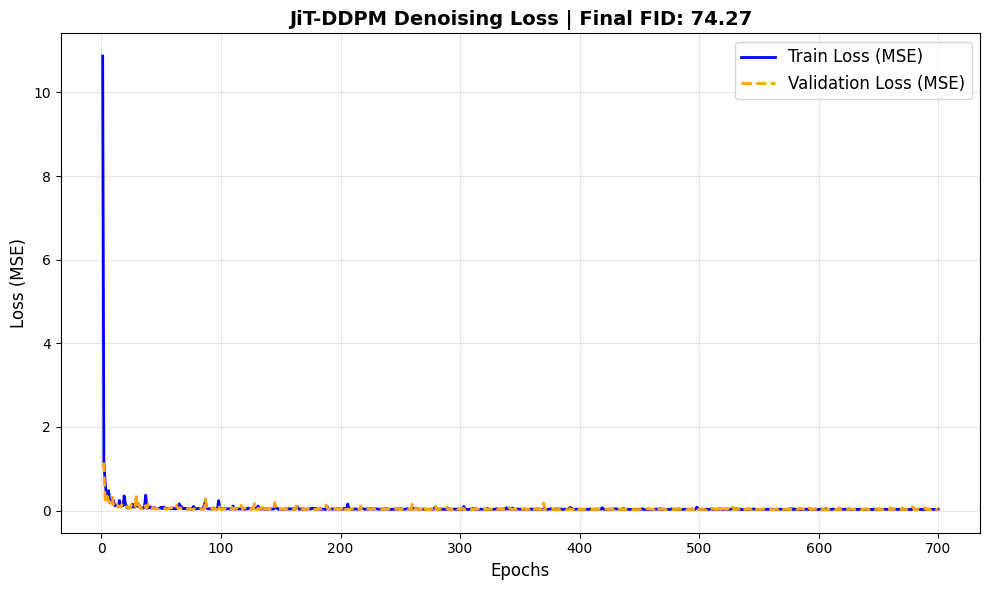


Unconditional Generated Lenses (JiT-DDPM EMA Model):


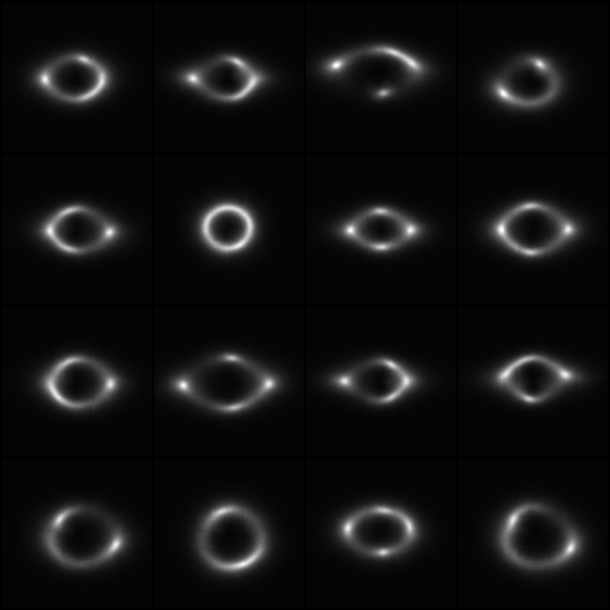

In [4]:
import mlflow
from IPython.display import display
import tempfile

client = mlflow.tracking.MlflowClient()

train_loss_history = client.get_metric_history(BEST_RUN_ID, "avg_loss")
val_loss_history = client.get_metric_history(BEST_RUN_ID, "val_avg_loss")

epochs_train = [m.step for m in train_loss_history]
losses_train = [m.value for m in train_loss_history]

epochs_val = [m.step for m in val_loss_history]
losses_val = [m.value for m in val_loss_history]

final_fid = client.get_metric_history(BEST_RUN_ID, "val_fid")[-1].value

plt.figure(figsize=(10, 6))
plt.plot(epochs_train, losses_train, label='Train Loss (MSE)', color='blue', linewidth=2)
plt.plot(epochs_val, losses_val, label='Validation Loss (MSE)', color='orange', linewidth=2, linestyle='--')

plt.title(f"JiT-DDPM Denoising Loss | Final FID: {final_fid:.2f}", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

with tempfile.TemporaryDirectory() as tmp_dir:
    artifact_path = "samples/temp_sample_epoch_final.png" 
    
    try:
        local_path = client.download_artifacts(BEST_RUN_ID, artifact_path, tmp_dir)
        print("\nUnconditional Generated Lenses (JiT-DDPM EMA Model):")
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load generated image artifact. Make sure the path is correct in MLflow. Error: {e}")

In [5]:
# Initialize Hydra and load the config
with initialize(version_base=None, config_path="../configs"):
    # Freeze the exact configuration used for this task via overrides
    cfg = compose(
        config_name="config", 
        overrides=[
            "model=ddpm_jit_deeplense_diffusion",
            "dataset=deeplense_diffusion",
            "training.epochs=5",
            "sampling.sample_every_n_epochs=1",
            "experiment_name=demo_task8"
        ]
    )

print("Active Configuration Locked For Task 8:")
print(f"Model: {cfg.model.name} ({cfg.model.type})")
print(f"Dataset: {cfg.dataset.name}")
print(f"Epochs: {cfg.training.epochs}")

Active Configuration Locked For Task 8:
Model: ddpm_jit (diffusion)
Dataset: deeplense_diffusion
Epochs: 5


In [6]:
from src.data import get_dataloaders, get_datasets, get_stats as get_stats_fn
from src.data.config import DataConfig
from src.models import get_model
from src.training.trainer import Trainer
from src.metrics import get_metric

# Load Data
data_config = DataConfig(**cfg.dataset)
train_dataset, test_dataset = get_datasets(data_config)
train_loader, test_loader = get_dataloaders(data_config)
get_stats = get_stats_fn(data_config)

# Load Model
model = get_model(cfg)

# Load Metrics
metrics = {}
for metric_cfg in cfg.model.metrics.values():
    metrics[metric_cfg.name] = get_metric(metric_cfg, cfg)

# Setup Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.training.lr)

# Initialize Trainer
trainer = Trainer(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    test_dataset=test_dataset,
    optimizer=optimizer,
    get_stats=get_stats,
    config=cfg,
    start_epoch=1,
    metrics=metrics
)

Loading dataset: deeplense_diffusion
Loading dataset: deeplense_diffusion
Trainer initialized for mode: DIFFUSION
EMA enabled with decay rate: 0.9999


Fetching a fixed sample batch from the dataloader...


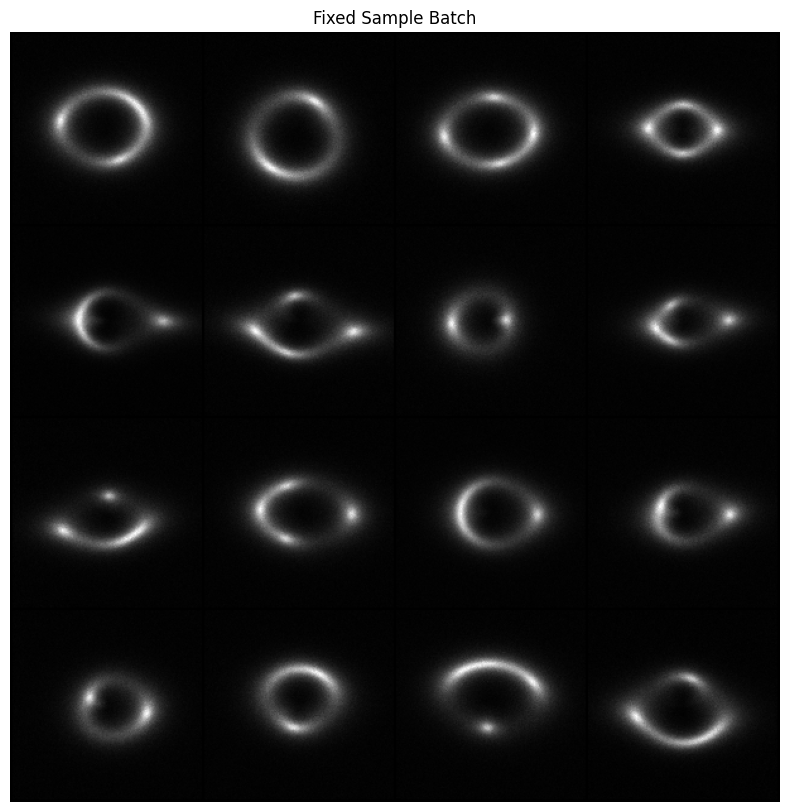

In [7]:
# Visualize what the model is about to see
print("Fetching a fixed sample batch from the dataloader...")
trainer.plot_fixed_batch()

In [8]:
# Start the MLflow run
mlflow.set_experiment(cfg.experiment_name)

with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"Started MLflow Run ID: {run_id}")
    
    # Run short 2-epoch demo
    trainer.train()
    
print("Demonstration training complete!")

Started MLflow Run ID: e0a9176afd0b4e498c5d79ba796296ec
Starting training from epoch 1...


Epoch 1: 100%|██████████| 141/141 [00:16<00:00,  8.37it/s, loss=0.477]


Epoch 1 - Average loss: 11.1382


val_1: 100%|██████████| 16/16 [00:00<00:00, 19.96it/s]


Average validation loss: 1.1379868313670158
Logged checkpoints for epoch 1 to MLFlow


...

Average validation loss: 0.3393535597715527


Sampling: 100%|██████████| 1000/1000 [00:21<00:00, 46.96it/s]


Logged side-by-side sample images for epoch final to MLFlow

Calculating FID Score for Epoch final
Generating 1000 images. This will take a moment...


Sampling: 100%|██████████| 1000/1000 [00:26<00:00, 38.20it/s]42.14s/it]


FID Score: 340.9749 (Logged to MLflow)

Training complete.
Demonstration training complete!


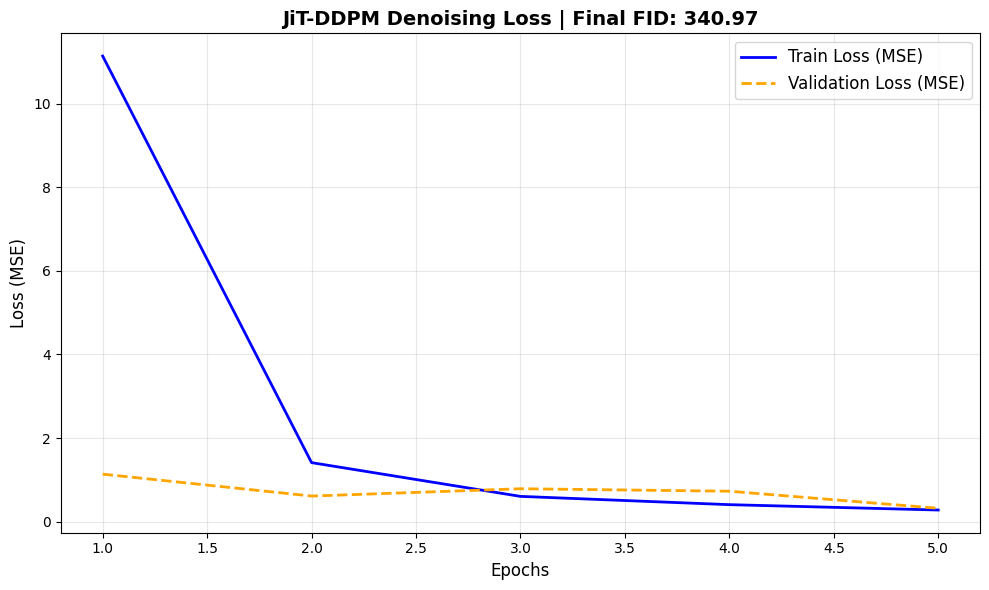


Unconditional Generated Lenses (JiT-DDPM EMA Model):


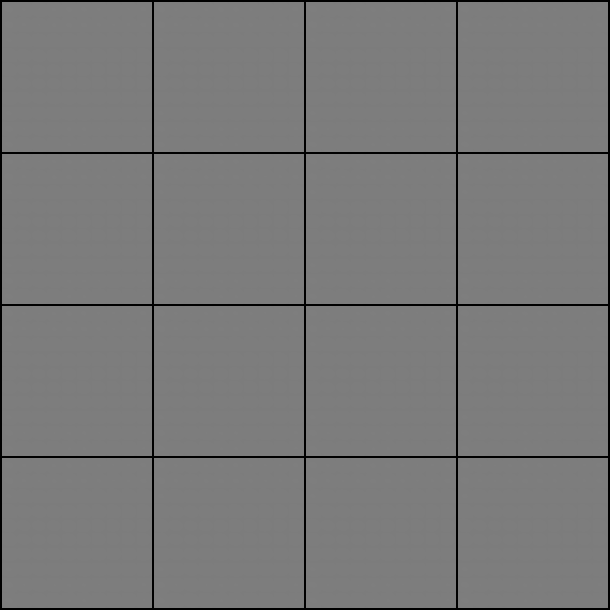

In [9]:
import mlflow
import matplotlib.pyplot as plt
from IPython.display import Image, display
import tempfile

client = mlflow.tracking.MlflowClient()

train_loss_history = client.get_metric_history(run_id, "avg_loss")
val_loss_history = client.get_metric_history(run_id, "val_avg_loss")

epochs_train = [m.step for m in train_loss_history]
losses_train = [m.value for m in train_loss_history]

epochs_val = [m.step for m in val_loss_history]
losses_val = [m.value for m in val_loss_history]

# Fetch final FID score
final_fid = client.get_metric_history(run_id, "val_fid")[-1].value

# 2. Plot Train & Val Loss on the same graph
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, losses_train, label='Train Loss (MSE)', color='blue', linewidth=2)
plt.plot(epochs_val, losses_val, label='Validation Loss (MSE)', color='orange', linewidth=2, linestyle='--')

plt.title(f"JiT-DDPM Denoising Loss | Final FID: {final_fid:.2f}", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

with tempfile.TemporaryDirectory() as tmp_dir:
    artifact_path = "samples/temp_sample_epoch_final.png" 
    
    try:
        local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
        print("\nUnconditional Generated Lenses (JiT-DDPM EMA Model):")
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load generated image artifact. Make sure the path is correct in MLflow. Error: {e}")

#### Obviously nothing visible at epoch 5 given it took 700 to converge :D